## 读取数据&查看数据基本信息

In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/coded_ideas_RA_semantic_精简.csv')

# 查看数据基本信息
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)


数据形状: (343, 41)

前5行数据:
   synthetic_id  category_1  category_2  category_3  category_4  category_5  \
0             1         1.0         3.0         1.0         NaN         NaN   
1             2         NaN         NaN         NaN         NaN         NaN   
2             3         1.0         NaN         NaN         NaN         NaN   
3             4         NaN         NaN         NaN         NaN         NaN   
4             5         3.0         NaN         NaN         NaN         NaN   

   category_6  category_7  category_8  category_9  ...  category_31  \
0         NaN         NaN         NaN         NaN  ...          NaN   
1         NaN         NaN         NaN         NaN  ...          NaN   
2         NaN         NaN         NaN         NaN  ...          NaN   
3         NaN         NaN         NaN         NaN  ...          NaN   
4         NaN         NaN         NaN         NaN  ...          NaN   

   category_32  category_33  category_34  category_35  category_36  \
0   

## 分离两组数据

In [35]:
# 分离两组数据
group1 = df.iloc[:, 1:21]  # category_1 到 category_20
group2 = df.iloc[:, 21:41]  # category_21 到 category_40

print("第一组 (category_1-20):")
print(f"列数: {group1.shape[1]}")
print(f"非空值数量: {group1.notna().sum().sum()}")
print(f"类别分布:\n{group1.stack().value_counts().sort_index()}")

print("\n" + "="*50)
print("第二组 (category_21-40):")
print(f"列数: {group2.shape[1]}")
print(f"非空值数量: {group2.notna().sum().sum()}")
print(f"类别分布:\n{group2.stack().value_counts().sort_index()}")


第一组 (category_1-20):
列数: 20
非空值数量: 547
类别分布:
1.0    344
2.0     23
3.0    179
4.0      1
Name: count, dtype: int64

第二组 (category_21-40):
列数: 20
非空值数量: 600
类别分布:
1.0    314
2.0     33
3.0    231
4.0     22
Name: count, dtype: int64


## 清洗数据

### 保留类型4

In [36]:
## 用NaN代替每个cell中不是 1.0, 2.0, 3.0, 4.0 的数据， 删除只有NaN数据的行

# 定义允许的值
allowed_values = [1.0, 2.0, 3.0, 4.0]

# --- 第一步：对所有列执行替换 ---
# 注意：非数字列（如字符串 'A'）因为不在 allowed_values 中，也会变成 NaN
group1 = group1.where(group1.isin(allowed_values), np.nan)
group2 = group2.where(group2.isin(allowed_values), np.nan)
                      
# --- 第二步：删除所有列全为 NaN 的行 ---

# how='all' 表示只有当一行中所有列都是 NaN 时才删除
group1 = group1.dropna(how='all').reset_index(drop=True)
group2 = group2.dropna(how='all').reset_index(drop=True)

### 不保留类型4---需要修改后续代码

In [27]:
## 用NaN代替每个cell中不是 1.0, 2.0, 3.0 的数据， 然后删除只有NaN数据的行

# 定义允许的值，因为值是 4.0 的源数据是乱填，无效回答，所以也清除
allowed_values = [1.0, 2.0, 3.0]

# --- 第一步：对所有列执行替换 ---
# 注意：非数字列（如字符串 'A'）因为不在 allowed_values 中，也会变成 NaN
group1 = group1.where(group1.isin(allowed_values), np.nan)
group2 = group2.where(group2.isin(allowed_values), np.nan)
                      
# --- 第二步：删除所有列全为 NaN 的行 ---

# how='all' 表示只有当一行中所有列都是 NaN 时才删除
group1 = group1.dropna(how='all').reset_index(drop=True)
group2 = group2.dropna(how='all').reset_index(drop=True)

## 两种方法比较两组人员的分布差异

### 计算每组的4个类别总计数分布

In [47]:
# 统计分析：比较两组人员在4个类别上的分布差异

# 1. 计算每组的频率分布
group1_counts = group1.stack().value_counts().sort_index()
group2_counts = group2.stack().value_counts().sort_index()

# 确保两组都有4个类别的数据
all_categories = [1, 2, 3, 4]
group1_counts = group1_counts.reindex(all_categories, fill_value=0)
group2_counts = group2_counts.reindex(all_categories, fill_value=0)

# 计算百分比
group1_total = group1_counts.sum()
group2_total = group2_counts.sum()
group1_pct = (group1_counts / group1_total * 100).round(2)
group2_pct = (group2_counts / group2_total * 100).round(2)

print("=" * 70)
print("两组人员分类结果对比")
print("=" * 70)
print(f"\n{'类别':<8} {'第一组(1-20)计数':<18} {'第一组占比%':<12} {'第二组(21-40)计数':<18} {'第二组占比%':<12}")
print("-" * 70)
for cat in all_categories:
    print(f"{int(cat):<8} {int(group1_counts[cat]):<18} {group1_pct[cat]:<12} {int(group2_counts[cat]):<18} {group2_pct[cat]:<12}")
print("-" * 70)
print(f"{'总计':<8} {int(group1_total):<18} {group1_pct.sum():<12.1f} {int(group2_total):<18} {group2_pct.sum():<12.1f}")


两组人员分类结果对比

类别       第一组(1-20)计数        第一组占比%       第二组(21-40)计数       第二组占比%      
----------------------------------------------------------------------
1        344                62.89        314                52.33       
2        23                 4.2          33                 5.5         
3        179                32.72        231                38.5        
4        1                  0.18         22                 3.67        
----------------------------------------------------------------------
总计       547                100.0        600                100.0       


### 统计每组中，4个类别的建议对应的人数
每组中给出4种建议的人数（一个人如果给出1条及以上的某个类别建议，就对该人在该类别的计数上计为1）。

然后基于它做Fisher 精确检验，得到的结果是：
无显著差异。P值: 8.8866e-01  。

统计得到并使用的频率计数如下：  
139, 20, 111, 1,    # 第一组频率计数  
138, 24, 117, 2,   # 第二组频率计数

In [53]:
# 包含所有5个值的统计（不包括NaN）
group1_counts = pd.Series({
    1: (group1 == 1.0).any(axis=1).sum(),
    2: (group1 == 2.0).any(axis=1).sum(),
    3: (group1 == 3.0).any(axis=1).sum(),
    4: (group1 == 4.0).any(axis=1).sum(),
    # 'NaN': group1.isna().any(axis=1).sum()
}, name='count')

group2_counts = pd.Series({
    1: (group2 == 1.0).any(axis=1).sum(),
    2: (group2 == 2.0).any(axis=1).sum(),
    3: (group2 == 3.0).any(axis=1).sum(),
    4: (group2 == 4.0).any(axis=1).sum(),
    # 'NaN': group1.isna().any(axis=1).sum()
}, name='count')

print(group1_counts)
print(group2_counts)

1    139
2     20
3    111
4      1
Name: count, dtype: int64
1    138
2     24
3    117
4      2
Name: count, dtype: int64


## 卡方检验（Chi-square test）

In [54]:
# 2. 卡方检验（Chi-square test）
# 构建列联表
contingency_table = pd.DataFrame({
    '第一组(1-20)': group1_counts,
    '第二组(21-40)': group2_counts
})

print("\n" + "=" * 70)
print("卡方检验 (Chi-square Test)")
print("=" * 70)
print("\n列联表:")
print(contingency_table)

# 进行卡方检验
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n卡方统计量: {chi2:.4f}")
print(f"自由度: {dof}")
print(f"p值: {p_value:.6f}")
print(f"\n期望频数:")
expected_df = pd.DataFrame(expected, 
                          index=[f'类别{int(i)}' for i in all_categories],
                          columns=['第一组(1-20)', '第二组(21-40)'])
print(expected_df.round(2))

# 判断显著性
alpha = 0.05
if p_value < alpha:
    print(f"\n结论: p值 < {alpha}，两组分类结果存在显著差异")
else:
    print(f"\n结论: p值 >= {alpha}，两组分类结果无显著差异")



卡方检验 (Chi-square Test)

列联表:
   第一组(1-20)  第二组(21-40)
1        139         138
2         20          24
3        111         117
4          1           2

卡方统计量: 0.6775
自由度: 3
p值: 0.878474

期望频数:
     第一组(1-20)  第二组(21-40)
类别1     135.99      141.01
类别2      21.60       22.40
类别3     111.93      116.07
类别4       1.47        1.53

结论: p值 >= 0.05，两组分类结果无显著差异


In [45]:
import pandas as pd
from scipy.stats import chi2_contingency

# 每组类别总数
group1_counts = group1.stack().value_counts()
group2_counts = group2.stack().value_counts()

table = pd.DataFrame([group1_counts, group2_counts]).fillna(0)

chi2, p, dof, exp = chi2_contingency(table)


print("p value : ",p)
print("chi2 value : ",chi2)
print("dof value : ",dof)
print("exp value : ",exp)

p value :  7.385605178680451e-06
chi2 value :  26.53017850671999
dof value :  3
exp value :  [[313.79773322 195.52746295  26.70619006  10.96861378]
 [344.20226678 214.47253705  29.29380994  12.03138622]]


## 效应量（Cramér's V）

In [55]:
# 3. 计算效应量（Cramér's V）
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"\nCramér's V (效应量): {cramers_v:.4f}")
print("效应量解释:")
print("  0.1 = 小效应")
print("  0.3 = 中等效应") 
print("  0.5 = 大效应")

if cramers_v < 0.1:
    effect_size = "小效应"
elif cramers_v < 0.3:
    effect_size = "小到中等效应"
elif cramers_v < 0.5:
    effect_size = "中等到大效应"
else:
    effect_size = "大效应"
print(f"\n当前效应量属于: {effect_size}")



Cramér's V (效应量): 0.0350
效应量解释:
  0.1 = 小效应
  0.3 = 中等效应
  0.5 = 大效应

当前效应量属于: 小效应


##  残差分析 

In [53]:

# 4. 残差分析 - 找出具体哪些类别存在差异
print("\n" + "=" * 70)
print("残差分析 (Residual Analysis)")
print("=" * 70)

# 计算标准化残差
observed = contingency_table.values
standardized_residuals = (observed - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(standardized_residuals,
                            index=[f'类别{int(i)}' for i in all_categories],
                            columns=['第一组(1-20)', '第二组(21-40)'])

print("\n标准化残差:")
print(residuals_df.round(3))
print("\n残差解释:")
print("  > +2: 该组在该类别上显著高于期望")
print("  < -2: 该组在该类别上显著低于期望")

print("\n具体差异:")
for i, cat in enumerate(all_categories):
    for j, group_name in enumerate(['第一组', '第二组']):
        res = standardized_residuals[i, j]
        if abs(res) > 2:
            direction = "显著高于" if res > 0 else "显著低于"
            print(f"  类别{int(cat)} - {group_name}: {direction}期望 (残差={res:.2f})")



残差分析 (Residual Analysis)

标准化残差:
     第一组(1-20)  第二组(21-40)
类别1      1.705      -1.628
类别2     -0.717       0.685
类别3     -1.182       1.129
类别4     -3.010       2.874

残差解释:
  > +2: 该组在该类别上显著高于期望
  < -2: 该组在该类别上显著低于期望

具体差异:
  类别4 - 第一组: 显著低于期望 (残差=-3.01)
  类别4 - 第二组: 显著高于期望 (残差=2.87)


## 百分比差异

In [54]:

# 5. 计算百分比差异
print("\n" + "=" * 70)
print("百分比差异分析")
print("=" * 70)

group1_total = group1_counts.sum()
group2_total = group2_counts.sum()
group1_pct = (group1_counts / group1_total * 100)
group2_pct = (group2_counts / group2_total * 100)

pct_diff = pd.DataFrame({
    '类别': [f'类别{int(i)}' for i in all_categories],
    '第一组占比%': group1_pct.values,
    '第二组占比%': group2_pct.values,
    '差异(第二组-第一组)': (group2_pct - group1_pct).values,
    '差异倍数': (group2_pct / group1_pct).replace([np.inf, -np.inf], np.nan).values
})

print(pct_diff.round(2).to_string(index=False))



百分比差异分析
 类别  第一组占比%  第二组占比%  差异(第二组-第一组)  差异倍数
类别1   62.89   52.33       -10.56  0.83
类别2    4.20    5.50         1.30  1.31
类别3   32.72   38.50         5.78  1.18
类别4    0.18    3.67         3.48 20.06


## 可视化对比

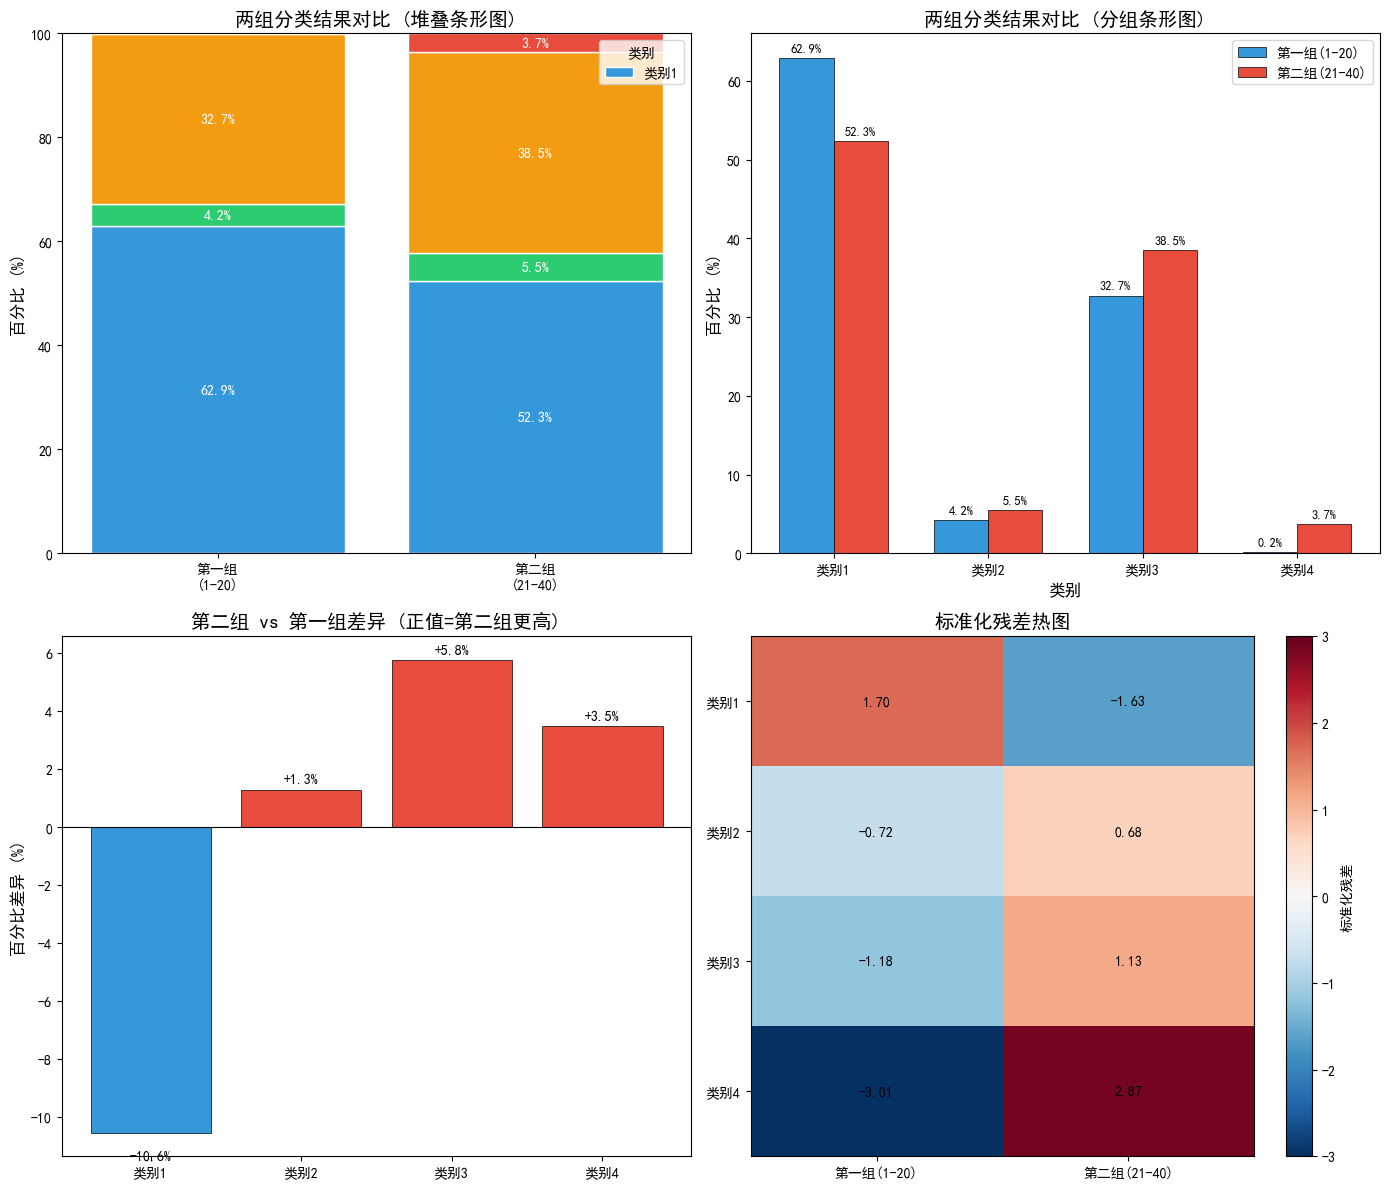

In [55]:
# 6. 可视化对比

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 图1: 堆叠条形图对比
ax1 = axes[0, 0]
x = ['第一组\n(1-20)', '第二组\n(21-40)']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
categories = ['类别1', '类别2', '类别3', '类别4']

bottom1 = 0
bottom2 = 0
for i, cat in enumerate(all_categories):
    values = [group1_pct.iloc[i], group2_pct.iloc[i]]
    ax1.bar(x[0], values[0], bottom=bottom1, label=categories[i] if i == 0 else "", 
            color=colors[i], edgecolor='white', linewidth=1)
    ax1.bar(x[1], values[1], bottom=bottom2, color=colors[i], edgecolor='white', linewidth=1)
    
    # 添加百分比标签
    if values[0] > 3:
        ax1.text(0, bottom1 + values[0]/2, f'{values[0]:.1f}%', 
                ha='center', va='center', fontweight='bold', color='white')
    if values[1] > 3:
        ax1.text(1, bottom2 + values[1]/2, f'{values[1]:.1f}%', 
                ha='center', va='center', fontweight='bold', color='white')
    
    bottom1 += values[0]
    bottom2 += values[1]

ax1.set_ylabel('百分比 (%)', fontsize=12)
ax1.set_title('两组分类结果对比 (堆叠条形图)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right', title='类别')

# 图2: 分组条形图
ax2 = axes[0, 1]
x_pos = np.arange(len(all_categories))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, group1_pct.values, width, label='第一组(1-20)', 
                color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax2.bar(x_pos + width/2, group2_pct.values, width, label='第二组(21-40)', 
                color='#e74c3c', edgecolor='black', linewidth=0.5)

ax2.set_xlabel('类别', fontsize=12)
ax2.set_ylabel('百分比 (%)', fontsize=12)
ax2.set_title('两组分类结果对比 (分组条形图)', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'类别{int(i)}' for i in all_categories])
ax2.legend()

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# 图3: 差异图
ax3 = axes[1, 0]
diff_values = (group2_pct - group1_pct).values
colors_diff = ['#e74c3c' if d > 0 else '#3498db' for d in diff_values]
bars = ax3.bar([f'类别{int(i)}' for i in all_categories], diff_values, color=colors_diff, 
               edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.set_ylabel('百分比差异 (%)', fontsize=12)
ax3.set_title('第二组 vs 第一组差异 (正值=第二组更高)', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax3.annotate(f'{height:+.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

# 图4: 残差热图
ax4 = axes[1, 1]
im = ax4.imshow(standardized_residuals, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['第一组(1-20)', '第二组(21-40)'])
ax4.set_yticks(range(len(all_categories)))
ax4.set_yticklabels([f'类别{int(i)}' for i in all_categories])
ax4.set_title('标准化残差热图', fontsize=14, fontweight='bold')

# 添加数值标注
for i in range(len(all_categories)):
    for j in range(2):
        text = ax4.text(j, i, f'{standardized_residuals[i, j]:.2f}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax4, label='标准化残差')

plt.tight_layout()
# plt.savefig('/mnt/kimi/output/group_comparison_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# print("\n图表已保存至: /mnt/kimi/output/group_comparison_analysis.png")


## 详细统计报告

In [56]:
# 生成详细统计报告
print("=" * 80)
print("                    两组人员分类结果差异统计分析报告")
print("=" * 80)

print("\n一、数据概况")
print("-" * 80)
print(f"  • 总样本量: {df.shape[0]} 人")
print(f"  • 第一组 (category_1-20): 共 {group1.notna().sum().sum()} 个分类记录")
print(f"  • 第二组 (category_21-40): 共 {group2.notna().sum().sum()} 个分类记录")
print(f"  • 分类类别: 1, 2, 3, 4")

print("\n二、分类分布对比")
print("-" * 80)
print(f"{'类别':<8} {'第一组计数':<12} {'第一组占比':<12} {'第二组计数':<12} {'第二组占比':<12} {'差异':<12}")
print("-" * 80)
for i, cat in enumerate(all_categories):
    diff_pct = group2_pct.iloc[i] - group1_pct.iloc[i]
    print(f"类别{int(cat):<4} {int(group1_counts.iloc[i]):<12} {group1_pct.iloc[i]:>6.2f}%      "
          f"{int(group2_counts.iloc[i]):<12} {group2_pct.iloc[i]:>6.2f}%      {diff_pct:>+6.2f}%")

print("\n三、卡方检验结果")
print("-" * 80)
print(f"  • 卡方统计量 (χ²): {chi2:.4f}")
print(f"  • 自由度 (df): {dof}")
print(f"  • p值: {p_value:.2e} ({'< 0.001' if p_value < 0.001 else f'{p_value:.4f}'})")
print(f"  • 效应量 (Cramér's V): {cramers_v:.4f}")
print(f"\n  结论: 两组分类结果存在{'极显著' if p_value < 0.001 else '显著' if p_value < 0.05 else '不显著'}差异")

print("\n四、主要发现")
print("-" * 80)
print("  1. 类别1 (最常用):")
print(f"     - 第一组使用最多 (62.89%)，第二组使用较少 (52.33%)")
print(f"     - 第二组比第一组少 10.56 个百分点")

print("\n  2. 类别2 (较少使用):")
print(f"     - 两组使用比例都较低 (第一组 4.20%, 第二组 5.50%)")
print(f"     - 差异不大 (+1.30 个百分点)")

print("\n  3. 类别3 (中等使用):")
print(f"     - 第二组使用更多 (38.50% vs 32.72%)")
print(f"     - 第二组比第一组多 5.78 个百分点")

print("\n  4. 类别4 (关键差异):")
print(f"     - 这是最显著的差异!")
print(f"     - 第一组几乎不使用 (0.18%, 仅1次)")
print(f"     - 第二组使用明显更多 (3.67%, 22次)")
print(f"     - 第二组是第一组的 20 倍!")
print(f"     - 标准化残差: 第一组 -3.01, 第二组 +2.87 (|残差| > 2, 显著)")

print("\n五、统计显著性检验")
print("-" * 80)
print("  标准化残差分析 (|残差| > 2 表示显著):")
for i, cat in enumerate(all_categories):
    res1 = standardized_residuals[i, 0]
    res2 = standardized_residuals[i, 1]
    sig1 = "***" if abs(res1) > 2 else ""
    sig2 = "***" if abs(res2) > 2 else ""
    print(f"    类别{int(cat)}: 第一组 {res1:+.2f} {sig1:<4} 第二组 {res2:+.2f} {sig2}")
print("    *** 表示 |残差| > 2，差异显著")

print("\n六、结论与建议")
print("-" * 80)
print("  1. 两组人员在分类行为上存在显著差异 (p < 0.001)")
print("  2. 主要差异体现在:")
print("     • 第一组更倾向于使用类别1")
print("     • 第二组更倾向于使用类别3和类别4")
print("     • 类别4是两组最大的分歧点")
print("  3. 建议:")
print("     • 检查两组人员是否接受了不同的分类培训")
print("     • 确认类别4的定义是否清晰，是否存在理解偏差")
print("     • 考虑对两组人员进行统一的分类标准培训")

print("\n" + "=" * 80)


                    两组人员分类结果差异统计分析报告

一、数据概况
--------------------------------------------------------------------------------
  • 总样本量: 343 人
  • 第一组 (category_1-20): 共 547 个分类记录
  • 第二组 (category_21-40): 共 600 个分类记录
  • 分类类别: 1, 2, 3, 4

二、分类分布对比
--------------------------------------------------------------------------------
类别       第一组计数        第一组占比        第二组计数        第二组占比        差异          
--------------------------------------------------------------------------------
类别1    344           62.89%      314           52.33%      -10.56%
类别2    23             4.20%      33             5.50%       +1.30%
类别3    179           32.72%      231           38.50%       +5.78%
类别4    1              0.18%      22             3.67%       +3.48%

三、卡方检验结果
--------------------------------------------------------------------------------
  • 卡方统计量 (χ²): 26.5302
  • 自由度 (df): 3
  • p值: 7.39e-06 (< 0.001)
  • 效应量 (Cramér's V): 0.1521

  结论: 两组分类结果存在极显著差异

四、主要发现
--------------------------------